In [ ]:
# feel freee to contribute!
# just pull request or message Tomas (slack or tomas.ahumada@noirlab.com)

import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

import pandas as pd
import numpy as np

# bokeh things!
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, RangeSlider, HoverTool 
from bokeh.layouts import column, gridplot 
from bokeh.io import show, output_notebook
from bokeh.application import Application
from bokeh.application.handlers import FunctionHandler

output_notebook()

In [35]:
# opening the file
# the file was created in by querying the Babamul broker, see the list of all the parameters queries in the next cell

df = pd.read_csv('babamul.csv',low_memory=False)
df

,diaSourceId,isDipole,isdiffpos,glint_trail,shape_flag,centroid_flag,psfFlux_flag,apFlux_flag,pixelFlags_streak,pixelFlags_cr,...,pixelFlags_saturated,pixelFlags_nodata,reliability,extendedness,snr_psf,trailFlux,psfChi2,psfNdata,magpsf,objectID
0,170028517762269188,False,True,False,True,True,True,True,False,False,...,False,False,0.310480,NaN,14.148404,NaN,1353.333740,1558,22.734301,313888627059327063
1,170032899836870745,True,True,False,True,False,False,False,False,False,...,False,False,0.213171,NaN,9.573616,NaN,2835.705078,1681,22.324696,313888627059327063
2,170032899993632792,False,True,False,True,True,True,True,False,False,...,False,False,0.222810,NaN,25.803537,NaN,2534.842041,1681,21.412580,313888627059327063
3,170032900106354838,True,True,False,False,False,False,False,False,False,...,False,False,0.131109,0.438026,11.494576,8862.450195,2557.539307,1681,22.117939,313888627059327063
4,170032900241096729,True,True,False,False,False,False,False,False,False,...,False,False,0.136720,0.380691,10.382855,9217.496094,3556.637207,1681,22.234726,313888627059327063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156506,170068130383003676,False,True,False,False,False,False,False,False,False,...,False,False,0.759668,0.125133,13.532114,3142.289307,1646.640137,1681,22.727921,sso21164728286393674
156507,170068130488385604,False,True,False,False,False,False,False,False,False,...,False,False,0.969417,0.309086,12.940001,6865.453125,1708.465088,1681,21.997669,sso21164728286393674
156508,170068130622603299,False,True,False,False,False,False,False,False,False,...,False,False,0.994797,0.538974,13.199947,6356.245605,1683.772339,1681,21.910961,sso21164728286393674
156509,170094456483610625,False,True,False,False,False,False,False,False,False,...,False,False,0.993522,0.027114,12.550715,5550.423828,1675.530396,1681,22.087578,sso21164728286393674


ERROR:tornado.application:Uncaught exception GET /ws (::1)
HTTPServerRequest(protocol='http', host='localhost:54040', method='GET', uri='/ws', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired.

In [28]:
# Here are the parameters queried from the broker Babamul
# we note that in Babamul diaObject is objectID

list(df.keys())

['diaSourceId',
 'isDipole',
 'isdiffpos',
 'glint_trail',
 'shape_flag',
 'centroid_flag',
 'psfFlux_flag',
 'apFlux_flag',
 'pixelFlags_streak',
 'pixelFlags_cr',
 'pixelFlags_bad',
 'pixelFlags_saturated',
 'pixelFlags_nodata',
 'reliability',
 'extendedness',
 'snr_psf',
 'trailFlux',
 'psfChi2',
 'psfNdata',
 'magpsf',
 'objectID']

array([[<Axes: title={'center': 'magpsf'}>]], dtype=object)

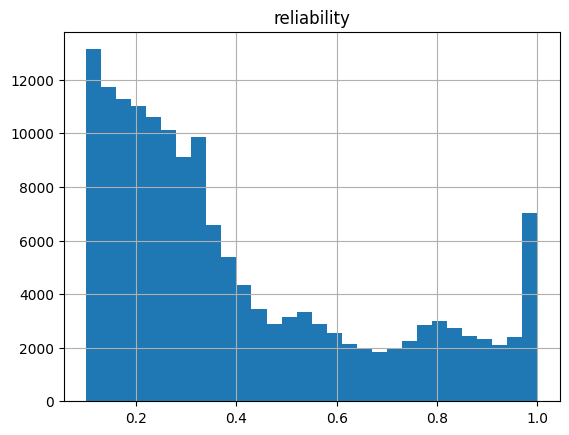

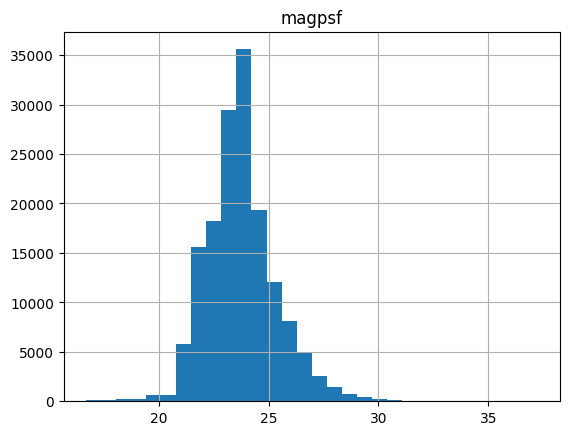

In [29]:
# quick histograms

df.hist(column='reliability', bins=30) #
df.hist(column='magpsf', bins=30) #


In [34]:
# the Bokeh block! I asked Google-Gemini to make this. Please play around with the data!
# I though magpsf would be a good proxy for real sources, but feel free to change that parameter.
# Some of the parameters are booleans, and you can use the toggle to color them in the plot


def lsst_dashboard(doc):
    # We will keep the original dataframe intact, and handle NaNs dynamically inside the callback
    plot_df = df.copy()

    # --- DYNAMICALLY SORT COLUMNS ---
    bool_cols = []
    num_cols = []
    
    for col in plot_df.columns:
        if pd.api.types.is_bool_dtype(plot_df[col]):
            bool_cols.append(col)
        elif pd.api.types.is_numeric_dtype(plot_df[col]):
            # If it's numeric but only contains 0s and 1s, it belongs in the color dropdown
            if plot_df[col].dropna().isin([0, 1]).all():
                bool_cols.append(col)
            else:
                # Otherwise, it's a true continuous number and belongs in the Axis dropdowns!
                num_cols.append(col)

    flag_options = ['None'] + bool_cols

    # --- INITIALIZE DATA SOURCES ---
    # I renamed the histogram sources to 'x' and 'y' since they are no longer hardcoded to reliability/extendedness
    scatter_source = ColumnDataSource(data=dict(x=[], y=[], mag=[], obj_id=[], color=[]))
    hist_x_source = ColumnDataSource(data=dict(top=[], bottom=[], left=[], right=[]))
    hist_y_source = ColumnDataSource(data=dict(top=[], bottom=[], left=[], right=[]))

    # --- 1. MAIN SCATTER PLOT ---
    p_scatter = figure(width=500, height=500, tools="pan,wheel_zoom,box_zoom,reset,lasso_select")
    hover = HoverTool(tooltips=[("Object ID", "@obj_id"), ("Mag (PSF)", "@mag{0.00}")])
    p_scatter.add_tools(hover)
    p_scatter.scatter(x='x', y='y', source=scatter_source, size=6, color='color', alpha=0.6)

    # --- 2. HISTOGRAMS ---
    p_hist_x = figure(width=500, height=150, x_range=p_scatter.x_range, x_axis_location=None, y_axis_location="left", tools="ypan,ywheel_zoom")
    p_hist_x.quad(top='top', bottom='bottom', left='left', right='right', source=hist_x_source, fill_color="teal", line_color="white", alpha=0.7)

    p_hist_y = figure(width=150, height=500, y_range=p_scatter.y_range, x_axis_location="below", y_axis_location=None, tools="xpan,xwheel_zoom")
    p_hist_y.quad(top='top', bottom='bottom', left='left', right='right', source=hist_y_source, fill_color="darkorange", line_color="white", alpha=0.7)

    # --- 3. WIDGETS ---
    min_mag = np.floor(plot_df['magpsf'].min()) if not plot_df['magpsf'].dropna().empty else 15
    max_mag = np.ceil(plot_df['magpsf'].max()) if not plot_df['magpsf'].dropna().empty else 25
    
    mag_slider = RangeSlider(start=min_mag, end=max_mag, value=(min_mag, max_mag), step=0.1, title="Magnitude (magpsf) Range")
    color_select = Select(title="Color Code by Flag:", value="None", options=flag_options)
    
    # NEW: X and Y Axis Selectors
    # We default them to reliability and extendedness if they exist, otherwise just pick the first available
    default_x = 'reliability' if 'reliability' in num_cols else num_cols[0]
    default_y = 'extendedness' if 'extendedness' in num_cols else num_cols[1] if len(num_cols) > 1 else num_cols[0]
    
    x_select = Select(title="X-Axis:", value=default_x, options=num_cols)
    y_select = Select(title="Y-Axis:", value=default_y, options=num_cols)

    # --- 4. THE PYTHON CALLBACK ---
    def update_plots(attr, old, new):
        min_thresh, max_thresh = mag_slider.value
        selected_flag = color_select.value
        x_col = x_select.value
        y_col = y_select.value
        
        # Filter by magnitude
        filtered_df = plot_df[(plot_df['magpsf'] >= min_thresh) & (plot_df['magpsf'] <= max_thresh)]

        # Determine colors
        if selected_flag == 'None' or selected_flag not in filtered_df.columns:
            colors = ["navy"] * len(filtered_df) 
        else:
            colors = ["crimson" if pd.notna(val) and float(val) == 1.0 else "navy" for val in filtered_df[selected_flag]]

        # Update Scatter Data
        scatter_source.data = dict(
            x=filtered_df[x_col], 
            y=filtered_df[y_col],
            mag=filtered_df['magpsf'],
            obj_id=filtered_df.get('objectId', ['N/A'] * len(filtered_df)),
            color=colors  
        )

        # Update Axis Labels Dynamically!
        p_scatter.xaxis.axis_label = x_col
        p_scatter.yaxis.axis_label = y_col

        if not filtered_df.empty:
            # We must drop NaNs for the specific columns right before calculating the histogram
            clean_x = filtered_df[x_col].dropna()
            if not clean_x.empty:
                x_hist, x_edges = np.histogram(clean_x, bins=20)
                hist_x_source.data = dict(top=x_hist, bottom=np.zeros(len(x_hist)), left=x_edges[:-1], right=x_edges[1:])

            clean_y = filtered_df[y_col].dropna()
            if not clean_y.empty:
                y_hist, y_edges = np.histogram(clean_y, bins=20)
                hist_y_source.data = dict(top=y_edges[1:], bottom=y_edges[:-1], left=np.zeros(len(y_hist)), right=y_hist)
        else:
            hist_x_source.data = dict(top=[], bottom=[], left=[], right=[])
            hist_y_source.data = dict(top=[], bottom=[], left=[], right=[])

    # Connect all four widgets to the update function
    mag_slider.on_change('value', update_plots)
    color_select.on_change('value', update_plots)
    x_select.on_change('value', update_plots)
    y_select.on_change('value', update_plots)
    
    update_plots(None, None, None)

    # --- 5. THE LAYOUT ---
    grid = gridplot([[p_hist_x, None], [p_scatter, p_hist_y]], merge_tools=False)
    
    # Organize controls into a 2x2 block
    controls = column(
        row(x_select, y_select),
        row(mag_slider, color_select)
    )
    
    layout = column(controls, grid)
    doc.add_root(layout)

# Launch the app
print('WARNING!! \n Message from Tomas: you need to add the port associated to your Jupyter notebook. \n Usually that number is 8888, but if it is different, it will fail!! ') 

port = '8890'
show(Application(FunctionHandler(lsst_dashboard)), notebook_url="localhost:"+port)

WARNING!! 
 Message from Tomas: you need to add the port associated to your Jupyter notebook. 
 Usually that number is 8888, but if it is different, it will fail!! 


ERROR:tornado.application:Uncaught exception GET /ws (::1)
HTTPServerRequest(protocol='http', host='localhost:54040', method='GET', uri='/ws', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/tahumada/miniconda3/envs/babamul/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired.